In [1]:
pip install tensorflow keras

Note: you may need to restart the kernel to use updated packages.


**============= Import Necessary Libraries =============**

In [3]:
# Step 1: Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical


**============= Dataset Loading =============**

In [4]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
print(f"📊 Training data shape: {x_train.shape}")
print(f"📊 Testing data shape: {x_test.shape}")

📊 Training data shape: (60000, 28, 28)
📊 Testing data shape: (10000, 28, 28)


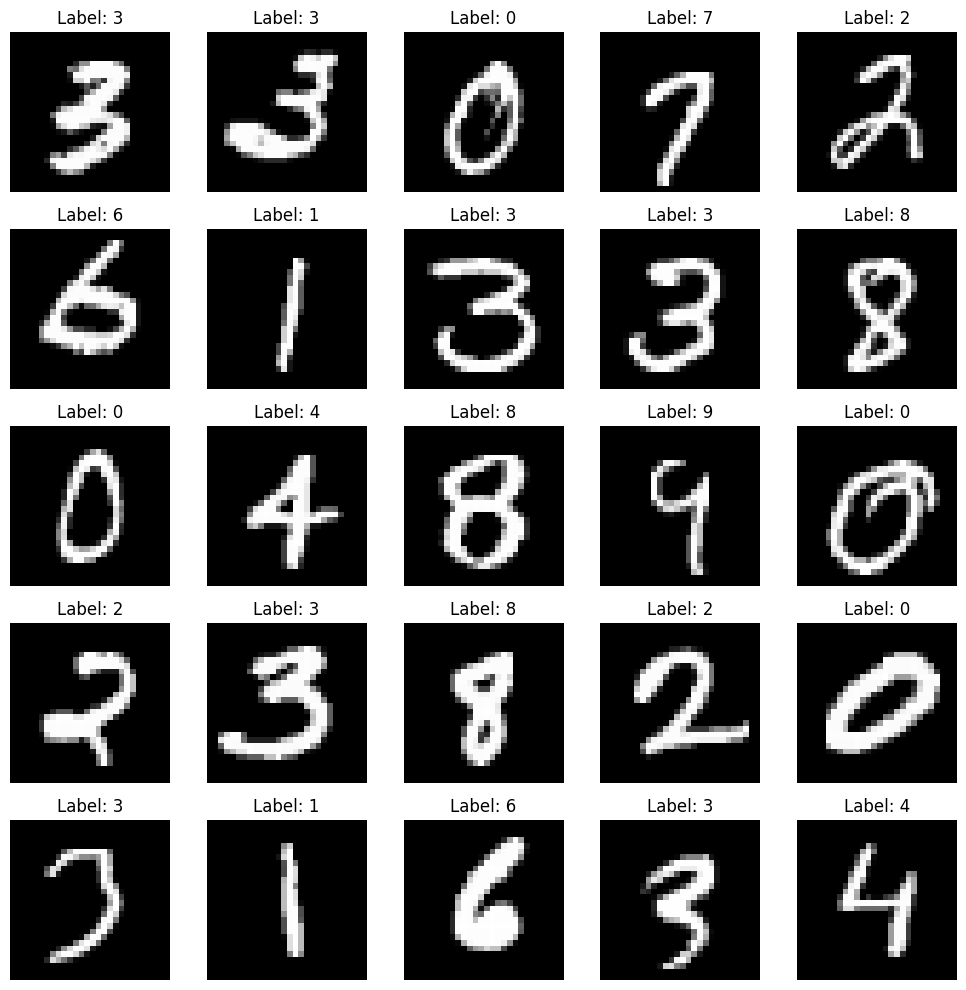

In [5]:
import numpy as np

plt.figure(figsize=(10, 10))
for i in range(25):
    idx = np.random.randint(0, x_train.shape[0])
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(f"Label: {y_train[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

**============= Data Preprocesing =============**

In [6]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print("📌 Pixel values normalized!")

📌 Pixel values normalized!


In [7]:
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)


print("===================== x_train_flat ===================== \n", x_train_flat)
print(x_train_flat.shape)


print("===================== x_test_flat ===================== \n", x_test_flat)
print(x_test_flat.shape)


===================== x_train_flat ===================== 
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(60000, 784)
===================== x_test_flat ===================== 
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(10000, 784)


In [8]:

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)


print("===================== x_train_cat ===================== \n", y_train_cat)
print(y_train_cat.shape)


print("===================== x_test_cat ===================== \n", y_test_cat)
print(y_test_cat.shape)


===================== x_train_cat ===================== 
 [[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]
(60000, 10)
===================== x_test_cat ===================== 
 [[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(10000, 10)


**============= Model Building =============**

***For ML, Linear SVM Model***

In [11]:
from sklearn.svm import LinearSVC
model = LinearSVC(max_iter=10000)  # increase iterations if needed
model.fit(x_train_flat, y_train)


LinearSVC(max_iter=10000)

In [12]:
from sklearn.metrics import accuracy_score


y_pred = model.predict(x_test_flat)

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", round(accuracy * 100, 2), "%")

Test Accuracy: 91.83 %


***For DL, CNN Model***

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train_cat, epochs=5, validation_data=(x_test, y_test_cat))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-15 17:34:48.502172: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.9046 - loss: 0.3054 - val_accuracy: 0.9808 - val_loss: 0.0586
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9851 - loss: 0.0506 - val_accuracy: 0.9850 - val_loss: 0.0461
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9900 - loss: 0.0324 - val_accuracy: 0.9855 - val_loss: 0.0443
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9932 - loss: 0.0222 - val_accuracy: 0.9867 - val_loss: 0.0398
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9951 - loss: 0.0147 - val_accuracy: 0.9863 - val_loss: 0.0428


In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9819 - loss: 0.0570
Test Accuracy: 0.986299991607666


**============= Visualization =============**

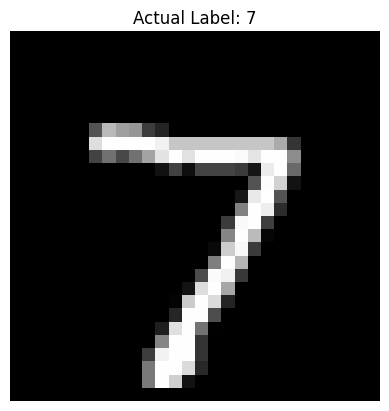

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Predicted Label: 7


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Show the image
plt.imshow(x_test[0], cmap='gray')
plt.axis('off')
plt.title("Actual Label: " + str(y_test[0]))
plt.show()

# Make prediction
prediction = model.predict(x_test[0].reshape(1, 28, 28, 1))
predicted_label = np.argmax(prediction)

print("Predicted Label:", predicted_label)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


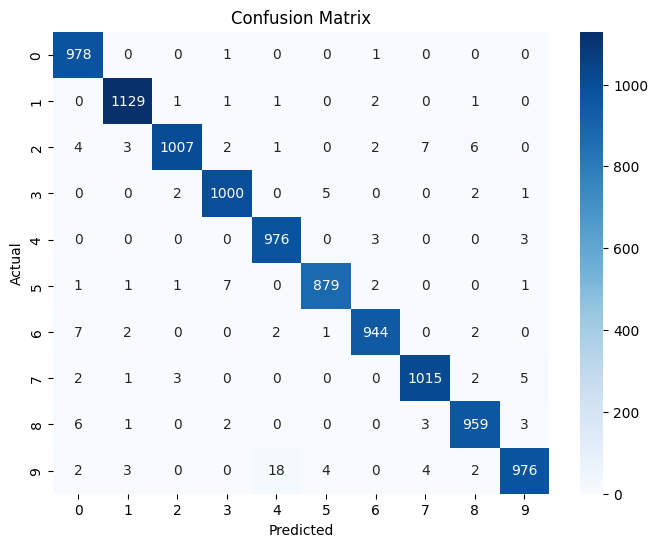

In [12]:
x_test_cnn = x_test.reshape(-1, 28, 28, 1)  # 4D input for CNN

y_pred = model.predict(x_test_cnn)
y_pred_labels = np.argmax(y_pred, axis=1)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [14]:
import tensorflow as tf

model.save("digit_model.keras")   # recommended by Keras team
model = tf.keras.models.load_model("digit_model.keras", compile=False)
print("Model is saved!")

Model is saved!


In [18]:
model.save("digit_model.h5")  # To save
model = tf.keras.models.load_model("digit_model.h5")  # To load
print("Model is saved!")

Model is saved!
